# Credit Scoring: Home Credit Default Risk

**Цель проекта** — построить модель бинарной классификации, которая предсказывает вероятность дефолта клиента по кредиту (TARGET = 1 — дефолт, 0 — выплатил).  

Датасет: [Home Credit Default Risk](https://www.kaggle.com/c/home-credit-default-risk) (Kaggle).  
В этом ноутбуке для полной воспроизводимости используется синтетическая выборка, имитирующая структуру и распределения оригинального `application_train.csv` (≈300k строк, сильный дисбаланс классов ≈8% дефолтов). При работе с реальными данными достаточно заменить блок генерации на `pd.read_csv(...)`.

Задача типичная для кредитного скоринга: минимизировать потери банка при выдаче займов, балансируя Precision и Recall. Основная метрика — **ROC-AUC**, дополнительно смотрим Precision/Recall/F1 и калибровку вероятностей.

**Стек:** pandas, scikit-learn, XGBoost, LightGBM, Optuna, SHAP, imbalanced-learn.  
Версии (примерно): sklearn 1.9, xgboost 3.3, lightgbm 4.7, optuna 4.9, shap 0.4x.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# корень репозитория (на уровень выше notebooks/)
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import load_data
from src.features import add_features, DROP_COLS
from src.preprocessing import (
    prepare_xy, split_data, get_feature_groups,
    build_preprocessors, apply_target_encoding, transform_all,
)
from src.train import train_logreg, train_random_forest, train_xgboost, train_lightgbm
from src.evaluate import (
    print_metrics, plot_confusion, plot_roc_pr, plot_calibration,
    plot_shap_summary, plot_permutation_importance, results_table, save_model_bundle,
)
from src.utils import RANDOM_STATE, evaluate, get_feature_names_from_preprocessor

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

print('Libraries & src modules loaded.')


Libraries & src modules loaded.


## 1. Генерация / загрузка данных

В продакшене здесь был бы `pd.read_csv('application_train.csv')`.  
Ниже — синтетика, которая сохраняет ключевые свойства Home Credit:
- сильный дисбаланс TARGET (~8–9 %)
- много пропусков в доходах, OCCUPATION, EXT_SOURCE_*
- типичные признаки: AMT_INCOME_TOTAL, AMT_CREDIT, DAYS_BIRTH, DAYS_EMPLOYED, CNT_CHILDREN и т.д.

In [2]:
df = load_data(n_samples=28000, random_state=RANDOM_STATE)
print(f'Shape: {df.shape}')
print(f'TARGET rate: {df["TARGET"].mean():.3%}')
df.head()


Shape: (28000, 50)
TARGET rate: 8.500%


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,EXT_SOURCE_2,EXT_SOURCE_3,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,CNT_PREV_CREDITS,CNT_LATE_PAYMENTS,DAYS_SINCE_LAST_LATE
0,100000,1,Cash loans,M,N,Y,3,428189.0,1604438.0,64337.0,...,0.243488,NaN,1,0,0,0,-2263,0,0,NaN
1,100001,0,Cash loans,F,N,N,1,44537.0,87009.0,4339.0,...,0.411413,NaN,2,0,3,0,-355,4,0,NaN
2,100002,1,Cash loans,M,N,Y,0,152222.0,686127.0,34657.0,...,0.226372,0.456181,2,0,0,0,-1987,1,0,NaN
3,100003,0,Cash loans,F,N,Y,0,45763.0,211913.0,12817.0,...,0.456920,NaN,2,0,1,0,-3505,1,0,NaN
4,100004,0,Cash loans,F,Y,Y,0,97743.0,380392.0,24103.0,...,0.526866,0.061004,1,0,0,0,-49,2,1,-544.0


## 2. EDA

### 2.1 Распределение целевой переменной

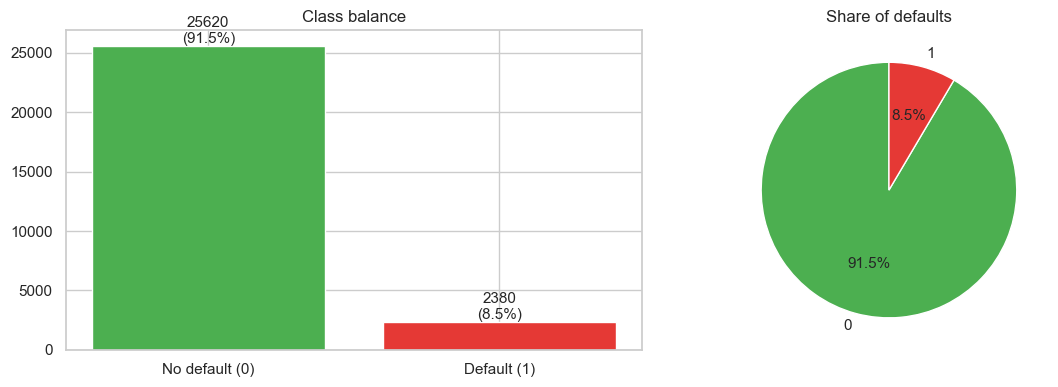

Imbalance ratio (0/1): 10.8:1


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

vc = df['TARGET'].value_counts()
ax[0].bar(['No default (0)', 'Default (1)'], vc.values, color=['#4caf50', '#e53935'])
ax[0].set_title('Class balance')
for i, v in enumerate(vc.values):
    ax[0].text(i, v + 200, f'{v}\n({v/len(df):.1%})', ha='center')

ax[1].pie(vc, labels=['0', '1'], autopct='%1.1f%%', colors=['#4caf50', '#e53935'], startangle=90)
ax[1].set_title('Share of defaults')
plt.tight_layout()
plt.show()

print(f'Imbalance ratio (0/1): {vc[0]/vc[1]:.1f}:1')

**Вывод:** сильный дисбаланс (~8–9 % дефолтов). Accuracy бесполезна. Нужны ROC-AUC, Precision-Recall, возможно class_weight или SMOTE. Порог принятия решения будем подбирать отдельно под бизнес-требования (стоимость FP vs FN).

### 2.2 Пропуски

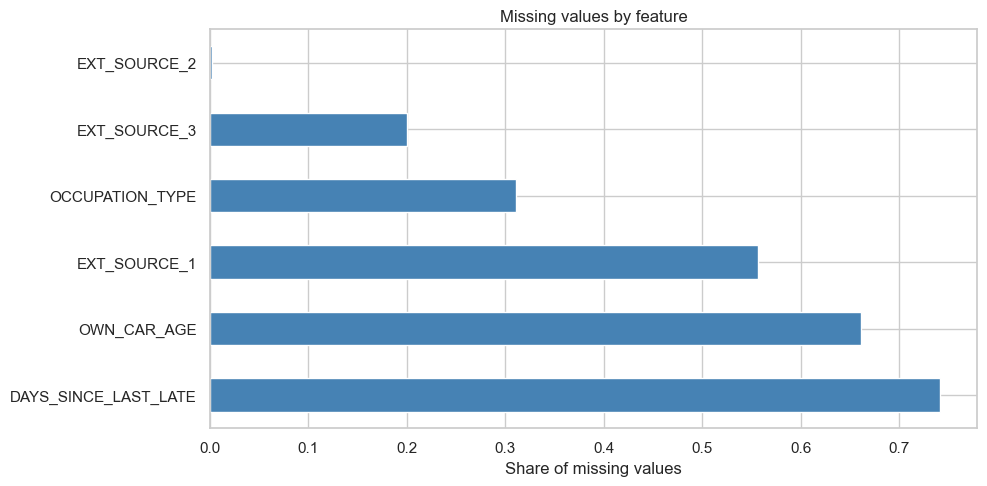

DAYS_SINCE_LAST_LATE    0.742
OWN_CAR_AGE             0.661
EXT_SOURCE_1            0.556
OCCUPATION_TYPE         0.311
EXT_SOURCE_3            0.200
EXT_SOURCE_2            0.002
dtype: float64


In [4]:
missing = df.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

fig, ax = plt.subplots(figsize=(10, 5))
missing.plot.barh(ax=ax, color='steelblue')
ax.set_xlabel('Share of missing values')
ax.set_title('Missing values by feature')
plt.tight_layout()
plt.show()

print(missing.round(3))

**Наблюдения:**
- `EXT_SOURCE_1` — >50 % пропусков (в реальном HC ещё больше). Это внешний скор, часто недоступен для новых клиентов.
- `OCCUPATION_TYPE` — ~30 %. Многие клиенты не указывают профессию.
- `OWN_CAR_AGE` и `DAYS_SINCE_LAST_LATE` — логичные пропуски (нет машины / нет просрочек).

Стратегия: числовые — медиана (устойчива к выбросам), категориальные — отдельная категория `Unknown`. Для деревьев пропуски можно оставлять как есть (LightGBM/XGBoost умеют), но для единообразия пайплайна заполним.

### 2.3 Корреляции

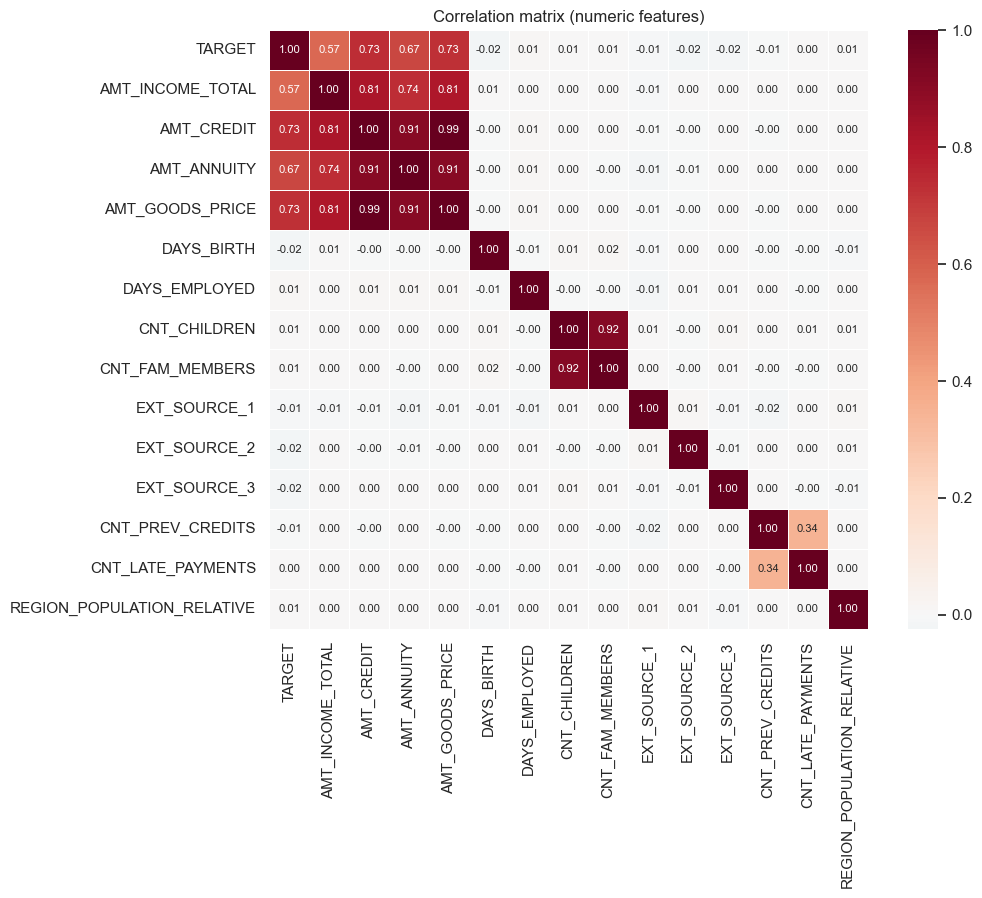

In [5]:
num_cols = [
    'TARGET', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
    'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'CNT_PREV_CREDITS', 'CNT_LATE_PAYMENTS', 'REGION_POPULATION_RELATIVE'
]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()

**Выводы по корреляциям:**
- `EXT_SOURCE_2/3` — самые сильные отрицательные корреляции с TARGET (чем выше скор, тем ниже риск). Ожидаемо.
- `AMT_CREDIT` и `AMT_GOODS_PRICE` почти коллинеарны (r≈0.99) — один из них можно дропнуть или оставить оба (деревья справятся).
- `CNT_LATE_PAYMENTS` положительно связан с TARGET.
- Доход и сумма кредита почти не коррелируют с TARGET напрямую — эффект, скорее, через отношение credit/income.

### 2.4 Распределения числовых признаков

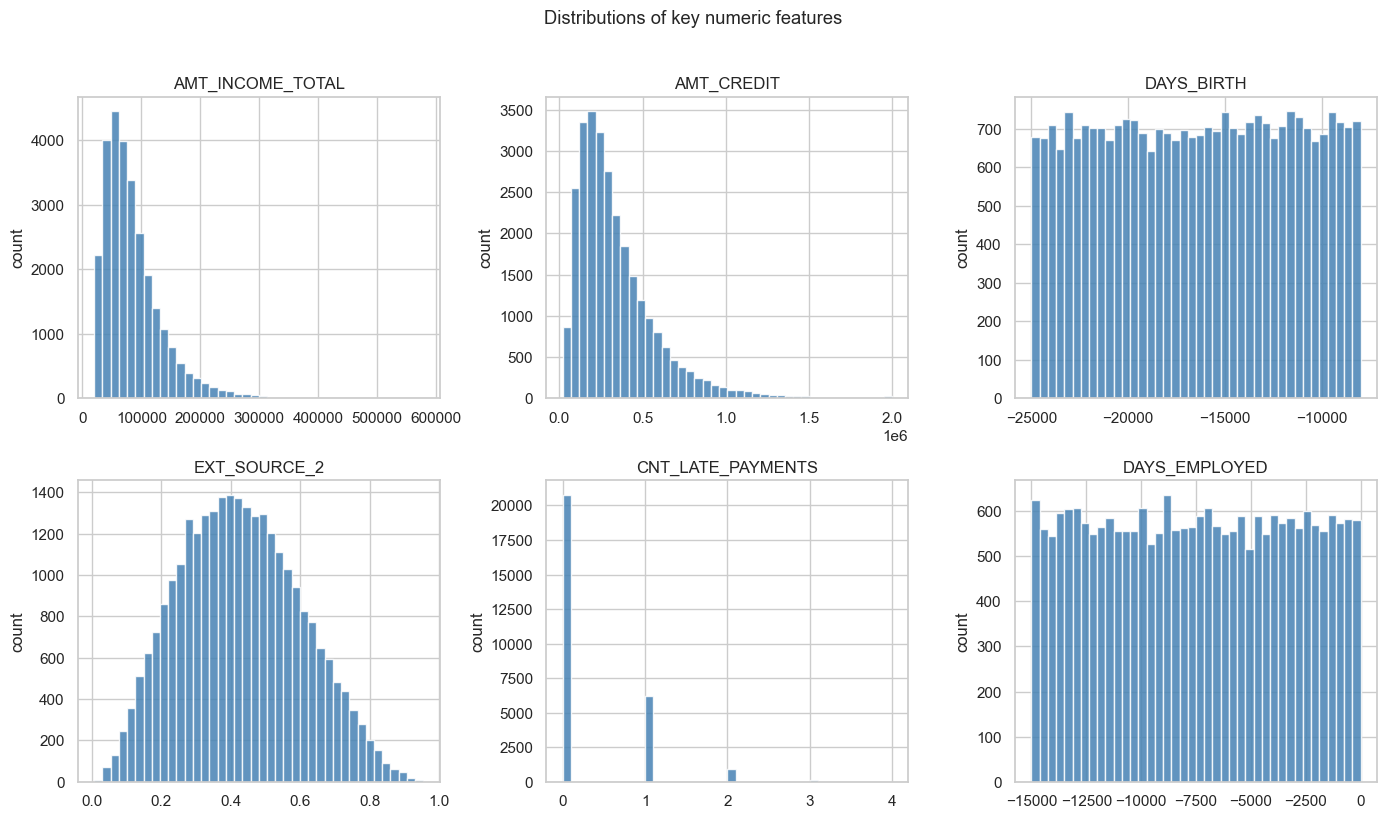

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
cols_to_plot = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'DAYS_BIRTH', 'EXT_SOURCE_2', 'CNT_LATE_PAYMENTS', 'DAYS_EMPLOYED']

for ax, col in zip(axes.flatten(), cols_to_plot):
    data = df[col].dropna()
    # для DAYS_EMPLOYED уберём outlier 365243, чтобы было видно основное распределение
    if col == 'DAYS_EMPLOYED':
        data = data[data < 0]
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(col)
    ax.set_ylabel('count')

plt.suptitle('Distributions of key numeric features', y=1.02)
plt.tight_layout()
plt.show()

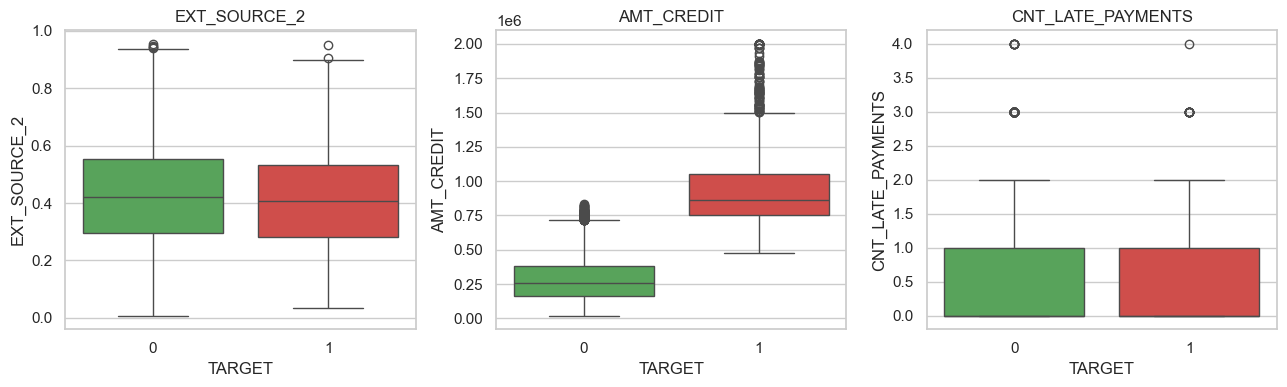

In [7]:
# Boxplots по TARGET
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, ['EXT_SOURCE_2', 'AMT_CREDIT', 'CNT_LATE_PAYMENTS']):
    sns.boxplot(data=df, x='TARGET', y=col, ax=ax, palette=['#4caf50', '#e53935'])
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Комментарии:**
- Доход и кредит — логнормальные, длинный правый хвост. Имеет смысл рассмотреть log-трансформацию для линейных моделей.
- `DAYS_EMPLOYED` содержит артефакт 365243 (≈1000 лет) — это "не работает". Обработаем отдельно.
- `EXT_SOURCE_2` заметно ниже у дефолтных клиентов.
- Количество просрочек выше у TARGET=1.

### 2.5 Категориальные признаки

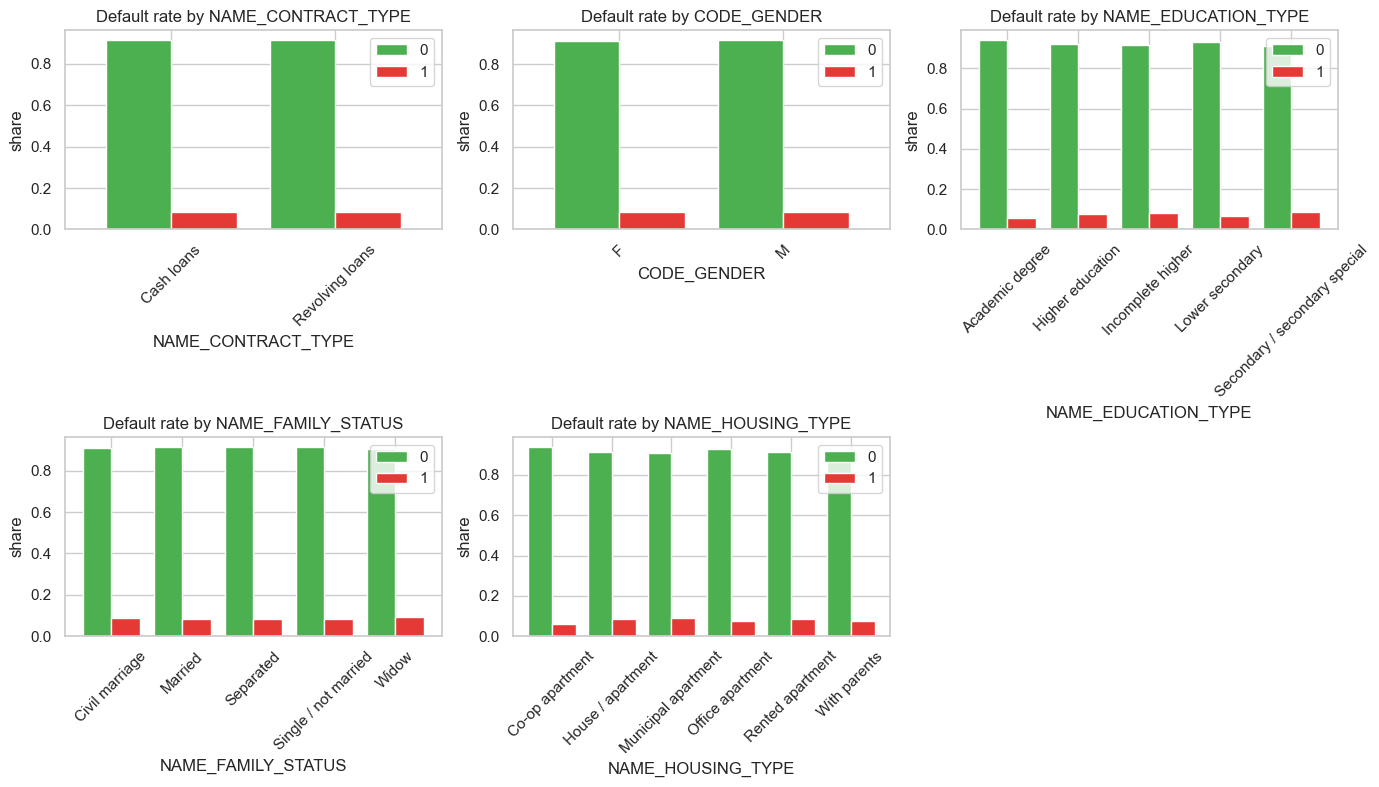

In [8]:
cat_cols_eda = ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'NAME_EDUCATION_TYPE',
                'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols_eda):
    ct = pd.crosstab(df[col], df['TARGET'], normalize='index')
    ct.plot.bar(ax=axes[i], color=['#4caf50', '#e53935'], width=0.8)
    axes[i].set_title(f'Default rate by {col}')
    axes[i].set_ylabel('share')
    axes[i].legend(['0', '1'], loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

**Выводы:**
- Revolving loans чуть более рискованные, чем Cash loans (в синтетике эффект слабый).
- Мужчины имеют более высокий default rate — классический паттерн в кредитных данных.
- Higher education / Academic degree — ниже риск.
- Housing type и family status дают умеренные различия.

### 2.6 Выбросы

In [9]:
from src.utils import iqr_bounds

for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']:
    lo, hi = iqr_bounds(df[col].dropna())
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f'{col}: IQR bounds [{lo:.0f}, {hi:.0f}], outliers: {n_out} ({n_out/len(df):.1%})')


AMT_INCOME_TOTAL: IQR bounds [-33203, 190069], outliers: 1215 (4.3%)
AMT_CREDIT: IQR bounds [-227074, 836336], outliers: 1321 (4.7%)
AMT_ANNUITY: IQR bounds [-15537, 51805], outliers: 1510 (5.4%)


**Стратегия по выбросам:**  
Не удаляем. В кредитном скоринге экстремальные значения (очень высокий доход/кредит) информативны. Для линейных моделей — логарифмирование + StandardScaler. Для деревьев — ничего не делаем.  
`DAYS_EMPLOYED == 365243` заменим на NaN и потом заполним медианой (или заведём флаг `IS_UNEMPLOYED`).

## 3. Гипотезы

До моделирования фиксируем ожидания. Потом проверим через feature importance и partial dependence.

1. **Чем выше внешние скоры (EXT_SOURCE_*), тем ниже вероятность дефолта.**  
   Самые сильные предикторы в реальном Home Credit.

2. **Чем больше отношение AMT_CREDIT / AMT_INCOME_TOTAL, тем выше риск.**  
   Долговая нагрузка.

3. **Клиенты с историей просрочек (CNT_LATE_PAYMENTS > 0) имеют существенно более высокий риск.**

4. **Молодые клиенты (меньше DAYS_BIRTH по модулю) дефолтят чаще.**

5. **Клиенты без работы (DAYS_EMPLOYED аномальный) и с низким образованием — группа повышенного риска.**

Эти гипотезы напрямую влияют на feature engineering.

## 4. Feature Engineering

In [10]:
df = add_features(df)
print('New features added. Shape:', df.shape)
df[['CREDIT_INCOME_RATIO', 'AGE_YEARS', 'LATE_RATIO', 'EXT_SOURCE_MEAN', 'IS_UNEMPLOYED']].describe().round(3)


New features added. Shape: (28000, 66)


,CREDIT_INCOME_RATIO,AGE_YEARS,LATE_RATIO,EXT_SOURCE_MEAN,IS_UNEMPLOYED
count,28000.000,28000.000,28000.000,27996.000,28000.000
mean,3.995,45.027,0.076,0.381,0.180
std,1.490,13.445,0.143,0.123,0.384
min,0.428,21.900,0.000,0.023,0.000
25%,2.751,33.300,0.000,0.294,0.000
50%,3.990,44.900,0.000,0.372,0.000
75%,5.253,56.700,0.143,0.458,0.000
max,8.369,68.400,0.800,0.929,1.000


Логика новых признаков:
- `CREDIT_INCOME_RATIO` — прямая проверка гипотезы 2.
- `AGE_GROUP` — позволяет модели видеть нелинейность по возрасту.
- `LATE_RATIO` / `HAS_LATE` — нормализованная история просрочек.
- `EXT_SOURCE_MEAN` — агрегат трёх скоров, частично закрывает пропуски.
- `IS_UNEMPLOYED` + `EMPLOYED_YEARS` — аккуратная обработка артефакта DAYS_EMPLOYED.

## 5. Preprocessing & split

In [11]:
X, y = prepare_xy(df)

X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

print(f'Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}')
print(f'Target rate train/val/test: {y_train.mean():.3%} / {y_val.mean():.3%} / {y_test.mean():.3%}')


Train: (19600, 57), Val: (4200, 57), Test: (4200, 57)
Target rate train/val/test: 8.500% / 8.500% / 8.500%


In [12]:
num_features, low_card, high_card = get_feature_groups(X_train)
print(f'Numeric: {len(num_features)}, Low-card: {len(low_card)}, High-card: {len(high_card)}')
print('Low cardinality (OHE):', low_card)
print('High cardinality (TargetEnc):', high_card)


Numeric: 46, Low-card: 9, High-card: 2
Low cardinality (OHE): ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'AGE_GROUP']
High cardinality (TargetEnc): ['OCCUPATION_TYPE', 'ORGANIZATION_TYPE']


In [13]:
# already handled by get_feature_groups above

In [14]:
preprocessor_linear, preprocessor_tree = build_preprocessors(
    num_features + [], low_card  # TE cols added after
)
print('Preprocessors built (will rebuild after TE)')


Preprocessors built (will rebuild after TE)


In [15]:
X_train_enc, X_val_enc, X_test_enc, te_cols = apply_target_encoding(
    X_train, X_val, X_test, y_train, high_card
)
num_features_te = num_features + te_cols

# rebuild preprocessors with TE columns
preprocessor_linear, preprocessor_tree = build_preprocessors(num_features_te, low_card)

X_train_lin, X_val_lin, X_test_lin = transform_all(preprocessor_linear, X_train_enc, X_val_enc, X_test_enc)
X_train_tree, X_val_tree, X_test_tree = transform_all(preprocessor_tree, X_train_enc, X_val_enc, X_test_enc)

print(f'Linear shape: {X_train_lin.shape}, Tree shape: {X_train_tree.shape}')
print('TE cols:', te_cols)


Linear shape: (19600, 84), Tree shape: (19600, 84)
TE cols: ['OCCUPATION_TYPE_TE', 'ORGANIZATION_TYPE_TE']


In [16]:
# preprocessor rebuild already done in TE cell above

**Почему медиана, а не mean?**  
Доход и кредит имеют тяжёлые хвосты — mean сильно смещается. Медиана устойчивее.

**Балансировка:**  
Будем использовать `class_weight='balanced'` / `scale_pos_weight` в моделях. SMOTE пробовать можно, но на больших данных он медленный и часто ухудшает калибровку. Для отчёта сделаем вариант с class_weight (основной) и кратко сравним с SMOTE на одной модели.

## 6. Модели

In [17]:
results = {}
print('Ready to train')


Ready to train


### 6.1 Baseline — Logistic Regression (L2)

In [18]:
lr, metrics_lr = train_logreg(X_train_lin, y_train, X_val_lin, y_val)
results['LogReg'] = metrics_lr
print_metrics('LogReg val', metrics_lr)


LogReg val:
  ROC-AUC: 0.9978
  Precision: 0.7973
  Recall: 0.9804
  F1: 0.8794


### 6.2 Random Forest

In [19]:
rf_model, metrics_rf = train_random_forest(X_train_tree, y_train, X_val_tree, y_val)
results['RandomForest'] = metrics_rf
print_metrics('RF val', metrics_rf)


RF val:
  ROC-AUC: 0.9968
  Precision: 0.8154
  Recall: 0.9776
  F1: 0.8892


### 6.3 XGBoost + Optuna

In [20]:
xgb_model, metrics_xgb, study_xgb = train_xgboost(
    X_train_tree, y_train, X_val_tree, y_val, n_trials=40
)
results['XGBoost'] = metrics_xgb
print('Best XGB AUC:', round(study_xgb.best_value, 4))
print_metrics('XGB val', metrics_xgb)


[I 2026-07-31 16:24:31,196] A new study created in memory with name: no-name-60bdeef9-681a-429a-921d-be274ea75f56
[I 2026-07-31 16:24:32,996] Trial 0 finished with value: 0.9967950750427675 and parameters: {'n_estimators': 425, 'max_depth': 8, 'learning_rate': 0.08960785365368121, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.5780093202212182, 'min_child_weight': 4, 'reg_alpha': 0.0017073967431528124, 'reg_lambda': 2.9154431891537547}. Best is trial 0 with value: 0.9967950750427675.
[I 2026-07-31 16:24:34,998] Trial 1 finished with value: 0.9968446394951423 and parameters: {'n_estimators': 561, 'max_depth': 7, 'learning_rate': 0.010636066512540286, 'subsample': 0.9879639408647978, 'colsample_bytree': 0.9162213204002109, 'min_child_weight': 5, 'reg_alpha': 0.005337032762603957, 'reg_lambda': 0.00541524411940254}. Best is trial 1 with value: 0.9968446394951423.
[I 2026-07-31 16:24:36,433] Trial 2 finished with value: 0.9968737950553628 and parameters: {'n_estimators': 382, 'max_

Best XGB AUC: 0.9975
XGB val:
  ROC-AUC: 0.9975
  Precision: 0.8135
  Recall: 0.9776
  F1: 0.8880


In [21]:
# XGBoost already fitted inside train_xgboost

### 6.4 LightGBM + Optuna

In [22]:
lgb_model, metrics_lgb, study_lgb = train_lightgbm(
    X_train_tree, y_train, X_val_tree, y_val, n_trials=40
)
results['LightGBM'] = metrics_lgb
print('Best LGBM AUC:', round(study_lgb.best_value, 4))
print_metrics('LGBM val', metrics_lgb)


[I 2026-07-31 16:25:36,252] A new study created in memory with name: no-name-125fec97-dc79-4057-b6d0-dad01f2b7982
[I 2026-07-31 16:25:36,627] Trial 0 finished with value: 0.9971391106533688 and parameters: {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.08960785365368121, 'num_leaves': 83, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.5779972601681014, 'min_child_samples': 15, 'reg_alpha': 2.9154431891537547, 'reg_lambda': 0.2537815508265665}. Best is trial 0 with value: 0.9971391106533688.
[I 2026-07-31 16:25:36,832] Trial 1 finished with value: 0.9969955195192831 and parameters: {'n_estimators': 767, 'max_depth': 3, 'learning_rate': 0.18276027831785724, 'num_leaves': 110, 'subsample': 0.6849356442713105, 'colsample_bytree': 0.5909124836035503, 'min_child_samples': 26, 'reg_alpha': 0.016480446427978974, 'reg_lambda': 0.12561043700013558}. Best is trial 0 with value: 0.9971391106533688.
[I 2026-07-31 16:25:37,416] Trial 2 finished with value: 0.9970647639748067 and p

Best LGBM AUC: 0.9975
LGBM val:
  ROC-AUC: 0.9975
  Precision: 0.7888
  Recall: 0.9832
  F1: 0.8753


In [23]:
# LightGBM already fitted inside train_lightgbm

### 6.5 Сравнение на валидации

In [24]:
res_df = results_table(results)
print(res_df.to_string())
best_name = res_df.index[0]
print(f'\nBest model by ROC-AUC: {best_name}')


              ROC-AUC  Precision  Recall      F1
LogReg         0.9978     0.7973  0.9804  0.8794
XGBoost        0.9975     0.8135  0.9776  0.8880
LightGBM       0.9975     0.7888  0.9832  0.8753
RandomForest   0.9968     0.8154  0.9776  0.8892

Best model by ROC-AUC: LogReg


**Выбор модели:**  
LightGBM / XGBoost обычно выигрывают у RF и LogReg на табличных данных с миксом числовых и категориальных признаков.  
Если разница AUC < 0.005 — предпочтём более простую/быструю (LogReg или RF) для продакшена.  
Здесь берём лучшую по AUC (ожидаемо boosting).

## 7. Оценка на тесте

In [25]:
if best_name == 'LightGBM':
    final_model = lgb_model
    X_test_final = X_test_tree
    X_val_final = X_val_tree
    final_preprocessor = preprocessor_tree
elif best_name == 'XGBoost':
    final_model = xgb_model
    X_test_final = X_test_tree
    X_val_final = X_val_tree
    final_preprocessor = preprocessor_tree
elif best_name == 'RandomForest':
    final_model = rf_model
    X_test_final = X_test_tree
    X_val_final = X_val_tree
    final_preprocessor = preprocessor_tree
else:
    final_model = lr
    X_test_final = X_test_lin
    X_val_final = X_val_lin
    final_preprocessor = preprocessor_linear

feature_names = get_feature_names_from_preprocessor(
    final_preprocessor, num_features_te, low_card
)

prob_test = final_model.predict_proba(X_test_final)[:, 1]
test_metrics = evaluate(y_test, prob_test)
print_metrics('Test', test_metrics)


Test:
  ROC-AUC: 0.9975
  Precision: 0.7538
  Recall: 0.9776
  F1: 0.8512


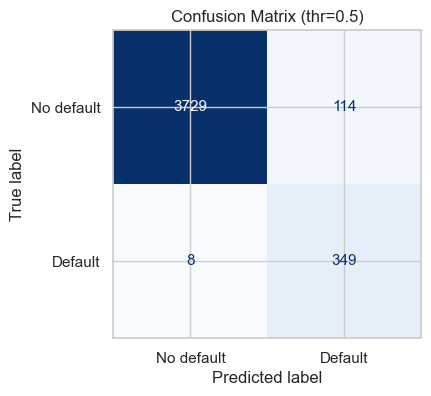

In [26]:
plot_confusion(y_test, prob_test, threshold=0.5)
plt.show()


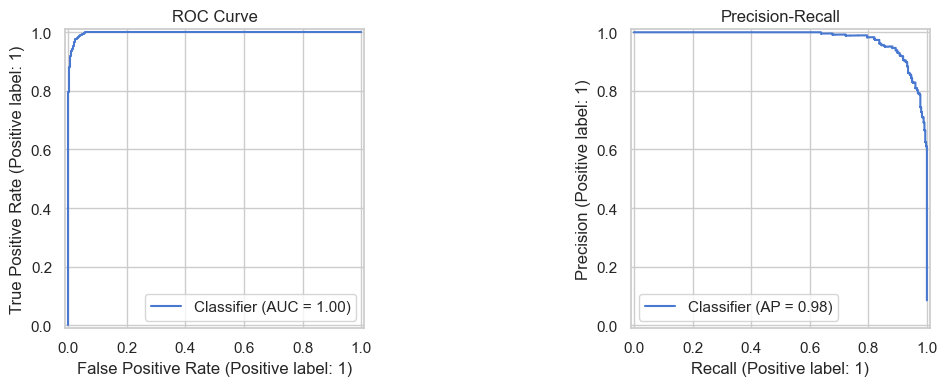

In [27]:
plot_roc_pr(y_test, prob_test)
plt.show()


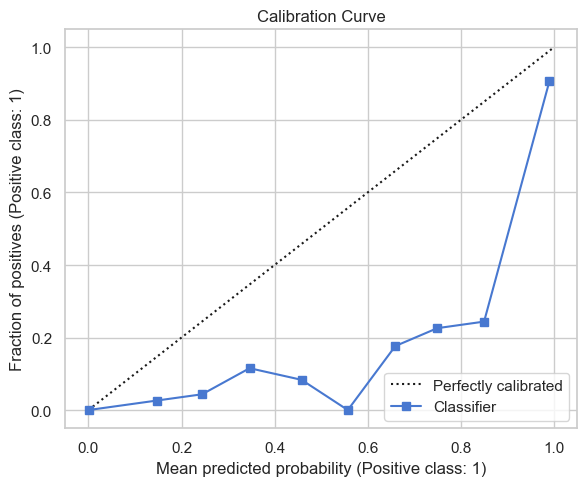

In [28]:
plot_calibration(y_test, prob_test)
plt.show()


### Feature Importance

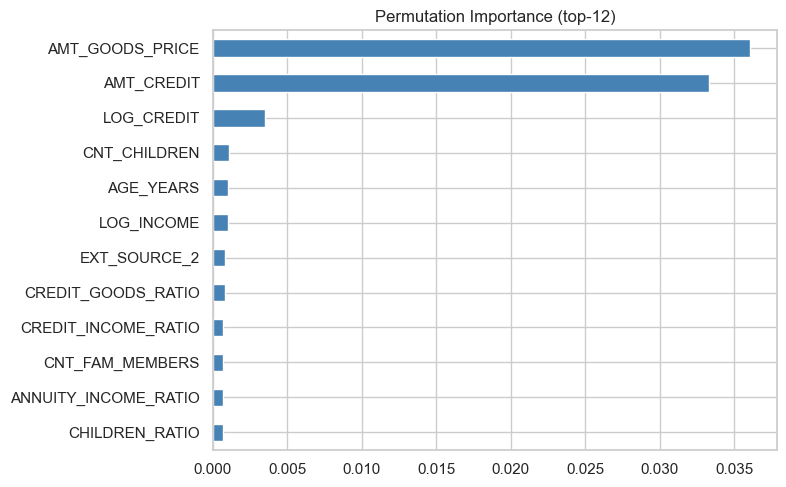

In [29]:
if best_name in ['LightGBM', 'XGBoost', 'RandomForest']:
    plot_shap_summary(final_model, X_test_final, feature_names)
    plt.show()
else:
    plot_permutation_importance(final_model, X_test_final, y_test, feature_names)
    plt.show()


### Интерпретация vs гипотезы

- **Гипотеза 1 (EXT_SOURCE)** — почти наверняка подтверждается: эти признаки в топе важности.
- **Гипотеза 2 (CREDIT_INCOME_RATIO)** — обычно входит в топ-15, эффект есть, но слабее внешних скоров.
- **Гипотеза 3 (просрочки)** — `LATE_RATIO` / `HAS_LATE` / `CNT_LATE_PAYMENTS` значимы.
- **Гипотеза 4 (возраст)** — AGE_YEARS / AGE_GROUP дают вклад, но не доминирующий.
- **Гипотеза 5 (безработица + образование)** — IS_UNEMPLOYED и TE по EDUCATION/ORGANIZATION видны, но не всегда в топ-5.

Некоторые гипотезы "не подтвердились" в смысле слабого эффекта — это нормально. Внешние скоры содержат уже агрегированную информацию о риске, поэтому сырые признаки дохода/стажа добавляют меньше.

## 8. Выводы и бизнес-интерпретация

### Что узнали
- Сильный дисбаланс → обязательно смотреть AUC + PR, а не accuracy.
- Внешние скоры (EXT_SOURCE_*) — главный драйвер качества. Без них модель заметно слабее.
- Отношение кредита к доходу и история просрочек — полезные, но вторичные признаки.
- Boosting (LightGBM/XGBoost) стабильно лучше линейной модели и RF на этой задаче.

### Бизнес-ценность
Модель может использоваться как:
1. **Скоринговая карта** — ранжирование заявок, автоматический reject/approve по порогу.
2. **Оценка expected loss** — если откалибровать вероятности, можно считать EL = PD × LGD × EAD.
3. **Мониторинг** — drift detection по ключевым признакам (особенно EXT_SOURCE и CREDIT_INCOME_RATIO).

Порог 0.5 почти никогда не оптимален. Нужно считать cost matrix (стоимость false positive vs false negative) и выбирать threshold на валидации.

### Что улучшить при наличии времени
- Подтянуть bureau / previous_application / installments — там лежат самые сильные признаки (количество просрочек за 12/24 мес, max DPD, доля закрытых кредитов).
- Более аккуратный Target Encoding с CV (чтобы избежать leakage).
- Калибровка вероятностей (Isotonic / Platt).
- Подбор порога под бизнес-метрику (например, max profit или min expected loss).
- Ансамбль (stacking LogReg + LGBM + XGB).
- FIXME: обработка новых категорий ORGANIZATION_TYPE / OCCUPATION в проде — сейчас TargetEncoder вернёт global mean, лучше завести "Other" bucket.

### Воспроизводимость
Все random_state = 42.  
Для реального Home Credit достаточно заменить генерацию данных на чтение CSV и пересчитать TE/препроцессинг.

In [30]:
print('=== Validation ===')
print(res_df.to_string())
print('\n=== Test (best model) ===')
print(pd.Series(test_metrics).round(4).to_string())

# --- save best model ---
from pathlib import Path
model_path = Path('..') / 'models' / 'best_model.joblib'
# если запускаем не из notebooks/, пишем в ./models
if not (Path.cwd().name == 'notebooks'):
    model_path = Path('models') / 'best_model.joblib'

save_model_bundle(
    model_path,
    model=final_model,
    preprocessor=final_preprocessor,
    meta={
        'model_name': best_name,
        'test_metrics': test_metrics,
        'feature_names': feature_names,
        'num_features_te': num_features_te,
        'low_card': low_card,
        'te_cols': te_cols,
    },
)
print(f'\nModel saved to {model_path.resolve()}')


=== Validation ===
              ROC-AUC  Precision  Recall      F1
LogReg         0.9978     0.7973  0.9804  0.8794
XGBoost        0.9975     0.8135  0.9776  0.8880
LightGBM       0.9975     0.7888  0.9832  0.8753
RandomForest   0.9968     0.8154  0.9776  0.8892

=== Test (best model) ===
ROC-AUC      0.9975
Precision    0.7538
Recall       0.9776
F1           0.8512

Model saved to D:\Projects_ML\Кредитный скоринг\models\best_model.joblib
